# OVERVIEW
This notebook serves as an example, and analysis of, the attached src notebook files

In [15]:
import sys
sys.path.append('../src')
sys.path.append('../../project1_market_analysis/src')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from risk_metrics import build_returns_matrix, annualised_stats, correlation_matrix, shrunk_covariance, risk_contributions
from optimisation import portfolio_stats, min_variance_portfolio, max_sharpe_portfolio, risk_parity_portfolio, efficient_frontier, stability_test, stability_test_shrunk, out_of_sample_test, compare_shorting,  turnover_analysis
from plotting import plot_efficient_frontier, plot_shorting_comparison


This notebooks focuses on the simple question, "given a selection of assets, what is the best way to weight the portolio?"
We start by building the returns and correlation matrices alongside annualised means

In [16]:
tickers = ["AAPL", "NVDA", "SPY", "JNJ", "GLD", "TSLA"]
returns_df = build_returns_matrix(tickers, period="5y")

print(f"Shape: {returns_df.shape}")
print(returns_df.head())

mu, cov = annualised_stats(returns_df)
print("\nAnnualised expected returns:")
print((mu * 100).round(2))

print("\nCorrelation matrix:")
print(correlation_matrix(returns_df).round(3))

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed

Shape: (1254, 6)
                AAPL      NVDA       SPY       JNJ       GLD      TSLA
Date                                                                  
2021-08-04 -0.002783  0.023164 -0.004919 -0.005906  0.000236  0.001663
2021-08-05  0.000749  0.017905  0.006333  0.001904 -0.003952  0.005219
2021-08-06 -0.004767 -0.013132  0.001652 -0.003339 -0.024991 -0.021732
2021-08-09 -0.000342 -0.003486 -0.000813  0.003466 -0.017736  0.020970
2021-08-10 -0.003354 -0.017689  0.001244  0.000346  0.000309 -0.005282

Annualised expected returns:
AAPL    19.11
NVDA    60.69
SPY     13.71
JNJ     11.87
GLD     17.43
TSLA    23.91
dtype: float64

Correlation matrix:
       AAPL   NVDA    SPY    JNJ    GLD   TSLA
AAPL  1.000  0.478  0.723  0.137  0.057  0.465
NVDA  0.478  1.000  0.708 -0.114  0.080  0.463
SPY   0.723  0.708  1.000  0.159  0.147  0.582
JNJ   0.137 -0.114  0.159  1.000  0.048 -0.043
GLD   0.057  0.080  0.147  0.048  1.000  0.054
TSLA  0.465  0.463  0.582 -0.043  0.054  1.000


We see that there is a diverse selection of assets chosen, with JNJ having minimal correlation with all other assets chosen. Similarly with gold. We now look at different common ways to weight these assets within a portfolio.

In [ ]:
mu_arr = mu.values
cov_arr = cov.values

#equal-weight portfolio
n = len(tickers)
w_equal = np.repeat(1/n, n)
ret, vol, sharpe = portfolio_stats(w_equal, mu_arr, cov_arr)
print(f"Equal weight:   return {ret*100:.2f}%, vol {vol*100:.2f}%, Sharpe {sharpe:.3f}")

# minimum variance portfolio
w_minvar = min_variance_portfolio(mu_arr, cov_arr)
ret, vol, sharpe = portfolio_stats(w_minvar, mu_arr, cov_arr)
print(f"Min variance:   return {ret*100:.2f}%, vol {vol*100:.2f}%, Sharpe {sharpe:.3f}")
print(dict(zip(tickers, w_minvar.round(3))))

# max sharpe portfolio
w_sharpe = max_sharpe_portfolio(mu_arr, cov_arr)
ret, vol, sharpe = portfolio_stats(w_sharpe, mu_arr, cov_arr)
print(f"Max Sharpe:     return {ret*100:.2f}%, vol {vol*100:.2f}%, Sharpe {sharpe:.3f}")
print(dict(zip(tickers, w_sharpe.round(3))))

Equal weight:   return 24.45%, vol 21.96%, Sharpe 1.114
Min variance:   return 14.20%, vol 11.36%, Sharpe 1.251
{'AAPL': np.float64(0.0), 'NVDA': np.float64(0.0), 'SPY': np.float64(0.327), 'JNJ': np.float64(0.361), 'GLD': np.float64(0.311), 'TSLA': np.float64(0.0)}
Max Sharpe:     return 24.14%, vol 14.74%, Sharpe 1.638
{'AAPL': np.float64(0.0), 'NVDA': np.float64(0.207), 'SPY': np.float64(0.0), 'JNJ': np.float64(0.4), 'GLD': np.float64(0.393), 'TSLA': np.float64(0.0)}


We see that the max-sharpe portfolio gives basically the same returns as the equal weight, but with 7% less risk, making it a significantly better choice. Infact, we now look the efficient frontier, a plot which gives the 'optimal' line for annualised expected returns vs risk taken.

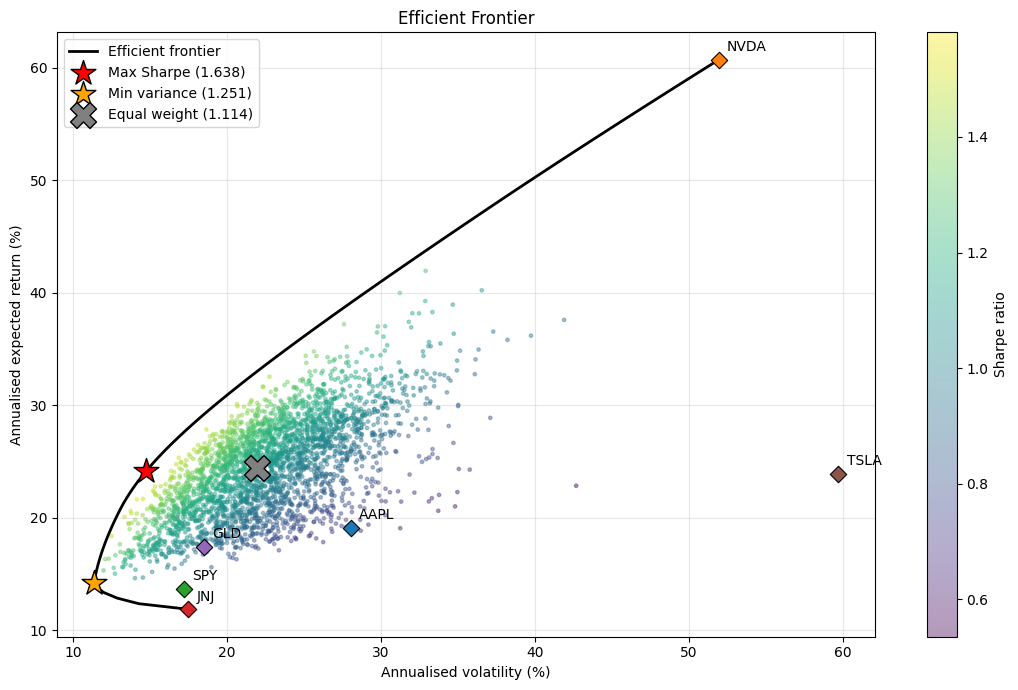

In [18]:
#as stated in plotting.py, the portfolios input takes in a dictionary of form: {label: (weights, colours, marker)}
vols, rets, weights = efficient_frontier(mu_arr, cov_arr, num_points=100)

portfolios = {
    'Max Sharpe':   (w_sharpe, 'red',    '*'),
    'Min variance': (w_minvar, 'orange', '*'),
    'Equal weight': (w_equal,  'grey',   'X'),
}

plot_efficient_frontier(mu_arr, cov_arr, tickers, vols, rets, portfolios=portfolios)

Each scatter point corresponds to a portfolio with different weights. The efficient frontier is the optimal weights when measured by returns and risk. For examaple, if you target 30% returns with this portfolio, you would need to take on ~19% risk. We also see how far away the equal-weighted portfolio is from the efficient frontier, highlighting how much it could be optimised. We now move on to discuss the stability of these portfolios.

In [19]:
stability = stability_test(returns_df, n_periods=4)
print("Max-Sharpe weights by sub-period:\n")
print((stability * 100).round(1))

print("\nWeight standard deviation across periods (pp):")
print((stability.std() * 100).round(1))

Max-Sharpe weights by sub-period:

                          AAPL  NVDA   SPY   JNJ   GLD  TSLA
2021-08-04 to 2022-10-31  21.2   0.0   0.0  62.1   0.0  16.7
2022-11-01 to 2024-02-01   0.0  38.4   0.0   0.0  61.6   0.0
2024-02-02 to 2025-05-02   0.0   8.1   0.0  12.4  75.9   3.5
2025-05-05 to 2026-08-03   8.7  12.8  27.4  48.2   2.9   0.0

Weight standard deviation across periods (pp):
AAPL    10.0
NVDA    16.6
SPY     13.7
JNJ     29.2
GLD     39.3
TSLA     7.9
dtype: float64


/Users/oscarlewis/Desktop/python/.venv/lib/python3.9/site-packages/numpy/_core/fromnumeric.py:57: FutureWarning: 'DataFrame.swapaxes' is deprecated and will be removed in a future version. Please use 'DataFrame.transpose' instead.
  return bound(*args, **kwds)


We see above that the weights are changing drastically per ticker per period, GLD, JNJ being the most alarming 2. This tells us that the system is primarily 'fitting the data' and not providing too much insight. It also requires us to liquidate each asset the system doesn't like every time, which is not too feasible. This is an issue, as the system entirely removes tickers it doesn't like. We seek to adapt it using Lediot-Wolf shrinkage.

This instabilty comes from our assets having to estimate too many quantites (all variances and all covariances) so any change can change these significantly(Mathematically, the covariance matrix could in theory have zero determinant, or very close to, and hence the problem is not well posed). We try to counteract this by taking a convex combination of a sample and a target (alternatively a weighted average), represented by this formula
$$
\Sigma_{shrunk} =(1 - \delta) \Sigma_{sample} + \delta F
$$
where F is our target and $ \delta $ is our shrinkage intensity and controls the blend. F is often a matrix assuming all assets share a common variance and single common correlation, which is almost certainly wrong, but its stable, and Ledoit-Wolf let us find the optimal $\delta$ to minimise least-squares error to data.

In [20]:
cov_shrunk, delta = shrunk_covariance(returns_df)
print(f"Shrinkage intensity: {delta:.4f}")

# Compare optimal weights: sample vs shrunk
w_sample = max_sharpe_portfolio(mu_arr, cov_arr)
w_shrunk = max_sharpe_portfolio(mu_arr, cov_shrunk)

comparison = pd.DataFrame({
    'Sample covariance': (w_sample * 100).round(1),
    'Shrunk covariance': (w_shrunk * 100).round(1)
}, index=tickers)
print("\nOptimal weights (%):")
print(comparison)
print()
stab_shrunk = stability_test_shrunk(returns_df, n_periods=4)
print((stab_shrunk * 100).round(1))
print("\nStd dev with shrinkage (pp):")
print((stab_shrunk.std() * 100).round(1))

Shrinkage intensity: 0.0099

Optimal weights (%):
      Sample covariance  Shrunk covariance
AAPL                0.0                0.0
NVDA               20.7               21.2
SPY                 0.0                0.0
JNJ                40.0               39.6
GLD                39.3               39.2
TSLA                0.0                0.0

                    AAPL  NVDA   SPY   JNJ   GLD  TSLA
2021-08 to 2022-10  22.6   0.0   0.0  60.1   0.0  17.3
2022-11 to 2024-02   0.0  43.2   0.0   0.0  56.8   0.0
2024-02 to 2025-05   0.0  10.6   0.0  13.5  71.3   4.6
2025-05 to 2026-08  10.8  14.9  22.3  48.2   3.9   0.0

Std dev with shrinkage (pp):
AAPL    10.8
NVDA    18.4
SPY     11.1
JNJ     28.3
GLD     36.4
TSLA     8.2
dtype: float64


/Users/oscarlewis/Desktop/python/.venv/lib/python3.9/site-packages/numpy/_core/fromnumeric.py:57: FutureWarning: 'DataFrame.swapaxes' is deprecated and will be removed in a future version. Please use 'DataFrame.transpose' instead.
  return bound(*args, **kwds)


We see that this approach has not particularly improved our issues. This is due to the actual issue here being the volatility of the returns over these periods, as seen below. The process above does improve things in a general theoretical sense though, as in principle the covariance matrix is likely unstable (determinant = 0 or very close to) and our process stabilises the matrix $ \forall \delta \in [0,1]$, with Ledoit-Wolf choosing the $\delta$ that minimises the operator norms of the 2 matrices.

In [21]:
splits = np.array_split(returns_df, 4)
means = pd.DataFrame([chunk.mean() * 252 * 100 for chunk in splits], index=[f"Period {i+1}" for i in range(4)])
print("Annualised mean returns by period (%):")
print(means.round(1))
print("\nStd dev across periods (pp):")
print(means.std().round(1))

Annualised mean returns by period (%):
          AAPL   NVDA   SPY   JNJ   GLD  TSLA
Period 1   8.7  -13.5  -6.9   3.8  -7.8  15.5
Period 2  19.3  136.0  21.6  -3.4  19.1   1.3
Period 3  12.8   65.7  14.8   3.7  37.4  57.5
Period 4  35.7   54.6  25.3  43.5  21.1  21.4

Std dev across periods (pp):
AAPL    11.9
NVDA    61.2
SPY     14.4
JNJ     21.3
GLD     18.7
TSLA    23.9
dtype: float64


/Users/oscarlewis/Desktop/python/.venv/lib/python3.9/site-packages/numpy/_core/fromnumeric.py:57: FutureWarning: 'DataFrame.swapaxes' is deprecated and will be removed in a future version. Please use 'DataFrame.transpose' instead.
  return bound(*args, **kwds)


We see that the returns are precisely the issue here and to combat this, we discuss risk parity, where we look at the assets risk per weighting it has in the portfolio. The idea is to choose asset weightings such that every asset has equal risk.

In [22]:
weight_rp = risk_parity_portfolio(cov_arr)
ret, vol, sharpe = portfolio_stats(weight_rp, mu_arr, cov_arr)

print(f"Risk parity: return {ret*100:.2f}%, vol {vol*100:.2f}%, Sharpe {sharpe:.3f}")
print("\nWeights (%):")
print(pd.Series(weight_rp * 100, index=tickers).round(1))

_, contrib_pct = risk_contributions(weight_rp, cov_arr)
print("\nRisk contributions (%) — should all be ~16.7:")
print(pd.Series(contrib_pct * 100, index=tickers).round(1))

_, contrib_equal = risk_contributions(w_equal, cov_arr)
print("\nRisk contributions under EQUAL weighting (%):")
print(pd.Series(contrib_equal * 100, index=tickers).round(1))

Risk parity: return 18.78%, vol 13.97%, Sharpe 1.344

Weights (%):
AAPL    11.8
NVDA     7.1
SPY     16.3
JNJ     31.2
GLD     27.3
TSLA     6.3
dtype: float64

Risk contributions (%) — should all be ~16.7:
AAPL    16.7
NVDA    16.7
SPY     16.7
JNJ     16.7
GLD     16.6
TSLA    16.6
dtype: float64

Risk contributions under EQUAL weighting (%):
AAPL    15.6
NVDA    31.3
SPY     11.3
JNJ      1.7
GLD      3.3
TSLA    36.8
dtype: float64


We see here that now the weightings of each asset are such that each one of them contributes to the risk of the portfolio equally. We show below where this portfolio lies relative to the efficient frontier.

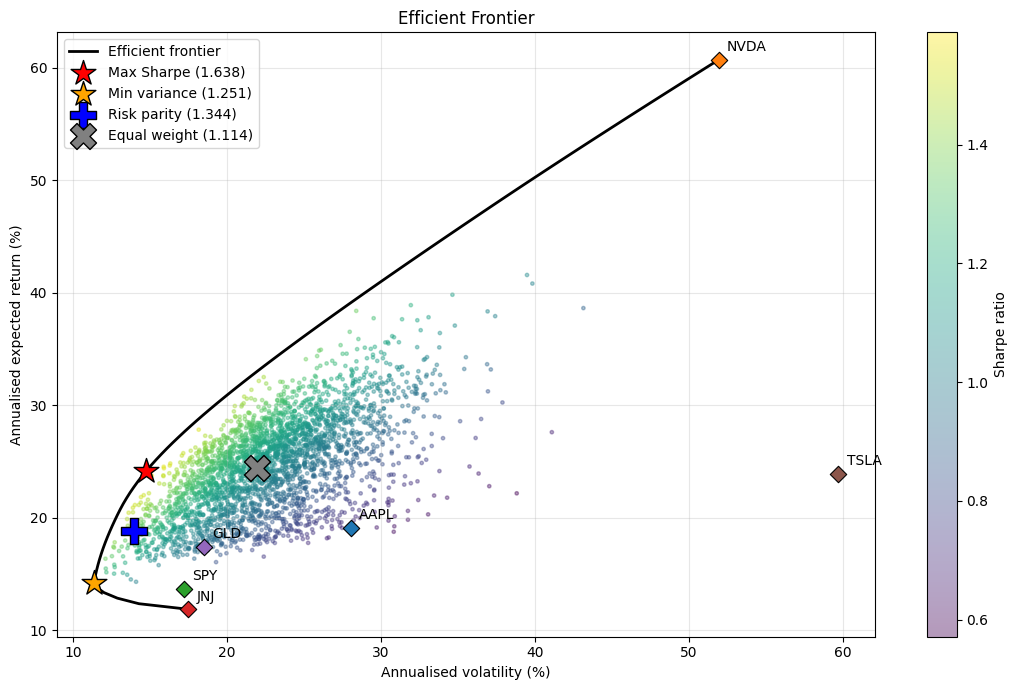

In [23]:

portfolios = {
    'Max Sharpe':   (w_sharpe, 'red',    '*'),
    'Min variance': (w_minvar, 'orange', '*'),
    'Risk parity':  (w_rp,     'blue',   'P'),
    'Equal weight': (w_equal,  'grey',   'X'),
}

plot_efficient_frontier(mu_arr, cov_arr, tickers, vols, rets, portfolios=portfolios)

We see that it doesn't lay directly on the efficent frontier, but pretty close to it, and on the lower volatility side of the plot in general. It achieves near optimal returns (per unit risk) without using any returns data what-so-ever. It gives a pretty safe way to structure a portfolio and a significantly better way than the equal weighting. We now impose a out of sample test, where we choose weightings based on the different portfolios defined on the first period, and see how they perform on the second period.

In [24]:
results, weights_oos = out_of_sample_test(returns_df, train_frac=0.6)

print("Performance:")
print(results)

print("\nWeights from training period (%):")
print((weights_oos * 100).round(1))

print("\nSharpe degradation (IS → OOS):")
print((results['OOS_Sharpe'] - results['IS_Sharpe']).round(3))

Train: 2021-08-04 to 2024-07-31  (752 days)
Test:  2024-08-01 to 2026-08-03  (502 days)

Performance:
                     IS_return  IS_vol  IS_Sharpe  OOS_return  OOS_vol  \
Strategy                                                                 
Max Sharpe               30.00   19.77      1.517       31.30    21.79   
Max Sharpe (shrunk)      30.85   20.34      1.517       31.46    22.01   
Min variance              7.52   10.25      0.733       25.97    13.98   
Risk parity              12.82   12.97      0.988       26.89    14.22   
Equal weight             21.92   22.53      0.973       28.26    21.08   

                     OOS_Sharpe  
Strategy                         
Max Sharpe                1.436  
Max Sharpe (shrunk)       1.430  
Min variance              1.857  
Risk parity               1.890  
Equal weight              1.341  

Weights from training period (%):
                     AAPL  NVDA   SPY   JNJ   GLD  TSLA
Max Sharpe            0.0  31.0   0.0   5.9  63.1 

It is key to note that the strategy names follow over, i.e "max sharpe" is the weightings chosen to maximise sharpe ratio over the in-sample data, hence why it is possible for it to not be the maximum sharpe ratio portfolio over the out-of-sample period. We see that the best performing portfolio was infact the risk parity one, but that every portfolio apart from the max sharpe portfolio. This indicates that the second period was just a better market period for our tickers, so the only conclusions we can take is comparatively. It also shows that the max sharpe ratio is not always the best choice for a portfolio as past performance may not indicate future performance. Something that has not been taken account of so far in any of my project is transaction costs/cost of totally liquidating one asset to move to another. This is where we look at this, and also introduce weight caps (i.e we cannot hold more than 30% of our portfolio in one asset, which helps diversify).

In [25]:
turnover = turnover_analysis(returns_df, n_periods=4, cost_bps=10)
print(turnover)


/Users/oscarlewis/Desktop/python/.venv/lib/python3.9/site-packages/numpy/_core/fromnumeric.py:57: FutureWarning: 'DataFrame.swapaxes' is deprecated and will be removed in a future version. Please use 'DataFrame.transpose' instead.
  return bound(*args, **kwds)


              Avg turnover  Max turnover  Cost per rebalance (%)
Strategy                                                        
Max Sharpe            68.9         100.0                   0.069
Min variance          19.5          34.1                   0.019
Risk parity           10.5          17.0                   0.011
Equal weight           0.0           0.0                   0.000


We see here that the max-sharpe portfolio has massive turnover in its assets, sometimes entirely liquidating them based upon the period. This costs significantly, for example if you were to rebalance 4 times annually, thats ~0.3% of your portfolio it costs you, which is significant. Comparitively, the risk parity portfolio does not encounter the same costs as turnover is minimal, just to retain equality in risk. We now see how a weight cap effects the max sharpe portfolio.

In [26]:
print("\n--- Effect of a maximum weight cap ---\n")

rows = []
for cap in [None, 0.5, 0.35, 0.25]:
    w = max_sharpe_portfolio(mu_arr, cov_arr, max_weight=cap)
    ret, vol, sharpe = portfolio_stats(w, mu_arr, cov_arr)
    row = {'Cap': 'None' if cap is None else f'{cap*100:.0f}%', 'Sharpe': round(sharpe, 3), 'Return': round(ret*100, 2), 'Vol': round(vol*100, 2)}
    row.update({t: round(v*100, 1) for t, v in zip(tickers, w)})
    rows.append(row)

print(pd.DataFrame(rows).set_index('Cap').to_string())


--- Effect of a maximum weight cap ---

      Sharpe  Return    Vol  AAPL  NVDA   SPY   JNJ   GLD  TSLA
Cap                                                            
None   1.638   24.14  14.74   0.0  20.7   0.0  40.0  39.3   0.0
50%    1.638   24.14  14.74   0.0  20.7   0.0  40.0  39.3   0.0
35%    1.608   25.56  15.89   7.0  23.0   0.0  35.0  35.0   0.0
25%    1.464   26.44  18.06   9.6  25.0  15.4  25.0  25.0   0.0


As the cap increases, we see a reduced sharpe ratio (as expected) but an increased amount of diversity as we increase the cap. By the 25% cap, we finally have weights in all of our tickers, as wanted for diversity. We see it also has more returns, but significantly more volality, so less sharpe ratio.

We end by discussion around shorting. Mathematically, this allows us to hold negative weights of assets, but our weights need to still sum to 1. This can bring greater returns, but takes on more risk than a long-only portfolio since we have more gross exposure to the market, i.e if we are funded by 150% long, 50% short, then we have correct weights but 200% gross exposure, which brings its own risks.

In [27]:
summary, weights_short = compare_shorting(mu_arr, cov_arr, tickers)
print(summary)
print("\nWeights (%):")
print(weights_short)

                  return    vol  sharpe  gross_exposure  largest_short
Strategy                                                              
Long only          24.14  14.74   1.638          100.00           0.00
Shorting allowed   32.23  18.76   1.718          222.72         -60.95

Weights (%):
                  AAPL  NVDA   SPY   JNJ   GLD  TSLA
Long only          0.0  20.7   0.0  40.0  39.3   0.0
Shorting allowed  15.3  35.9 -61.0  58.1  52.0  -0.4


We see that the best portfolio available shorting is by significantly shorting the S%P 500 and investing in other things elsewhere, including assets which are contained in it (AAPL, NVDA), so effectively the system is betting against other tickers in the S&P 500. Even though the volatility isn't too high here, the gross exposure is ~230% compared to 100%. In practical terms, this isn't great as we trade ~5% sharpe for 2.3x leverage. An increase in sharpe doesn't account for the potential risks of the theoretically unbounded losses of a short position

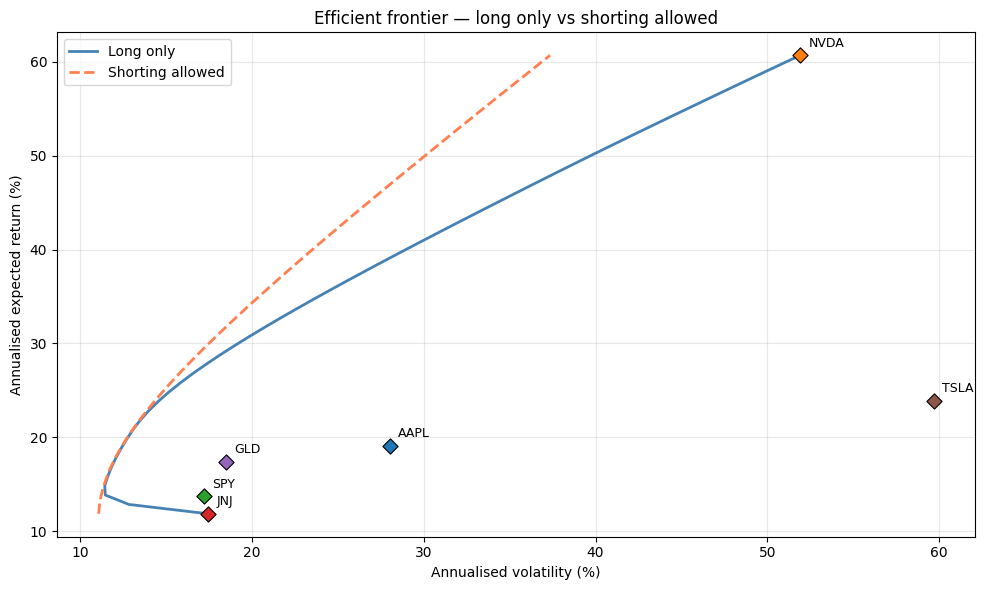

In [28]:
plot_shorting_comparison(mu_arr, cov_arr, tickers)

As seen above, the effective frontier does improve with the allowing of shortages, but cannot take into account extra factors of risk/leverage as mentioned.